In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("sales.csv", sep=";")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,3/1/2023,7/1/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...","16,448",2,"0,2","5,5512"
1,2,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,"3,54",2,"0,8","-5,487"
2,3,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,"11,784",3,"0,2","4,2717"
3,4,US-2023-112326,4/1/2023,8/1/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,"272,736",3,"0,2","-64,7748"
4,5,US-2023-141817,5/1/2023,12/1/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,"19,536",3,"0,2","4,884"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Row ID          10194 non-null  int64 
 1   Order ID        10194 non-null  object
 2   Order Date      10194 non-null  object
 3   Ship Date       10194 non-null  object
 4   Ship Mode       10194 non-null  object
 5   Customer ID     10194 non-null  object
 6   Customer Name   10194 non-null  object
 7   Segment         10194 non-null  object
 8   Country/Region  10194 non-null  object
 9   City            10194 non-null  object
 10  State/Province  10194 non-null  object
 11  Postal Code     10194 non-null  object
 12  Region          10194 non-null  object
 13  Product ID      10194 non-null  object
 14  Category        10194 non-null  object
 15  Sub-Category    10194 non-null  object
 16  Product Name    10194 non-null  object
 17  Sales           10194 non-null  object
 18  Quanti

In [5]:
df.describe()

,Row ID,Quantity
count,10194.000000,10194.000000
mean,5097.500000,3.791838
std,2942.898656,2.228317
min,1.000000,1.000000
25%,2549.250000,2.000000
50%,5097.500000,3.000000
75%,7645.750000,5.000000
max,10194.000000,14.000000


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [8]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country/Region    object
City              object
State/Province    object
Postal Code       object
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales             object
Quantity           int64
Discount          object
Profit            object
dtype: object

In [9]:
df["Sales"] = df["Sales"].str.replace(",", ".").astype(float)

df["Profit"] = df["Profit"].str.replace(",", ".").astype(float)

In [10]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Ventas Totales:", total_sales)
print("Ganancia Total:", total_profit)

Ventas Totales: 2326534.3543
Ganancia Total: 292296.8146


In [11]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


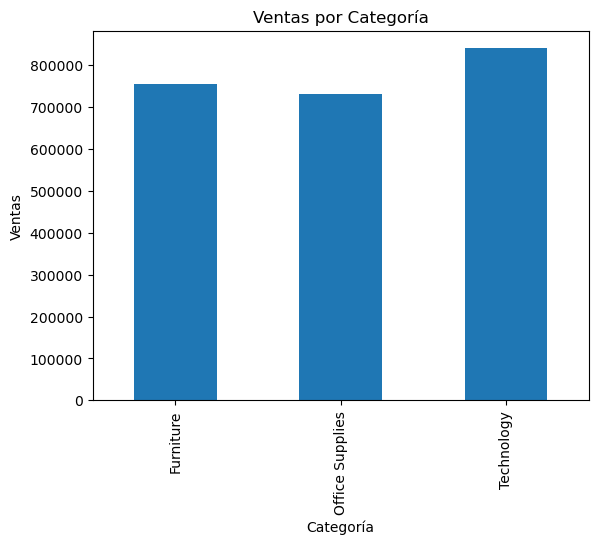

In [12]:
sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category.plot(kind="bar")

plt.title("Ventas por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")

plt.show()

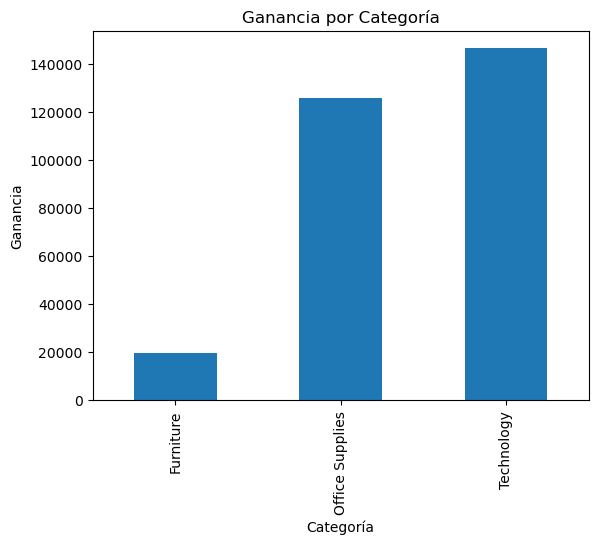

In [13]:
profit_by_category = df.groupby("Category")["Profit"].sum()

profit_by_category.plot(kind="bar")

plt.title("Ganancia por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ganancia")

plt.show()

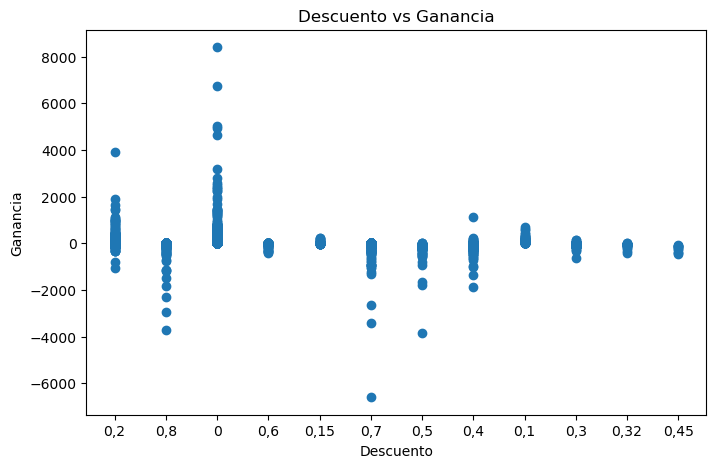

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Descuento vs Ganancia")
plt.xlabel("Descuento")
plt.ylabel("Ganancia")

plt.show()

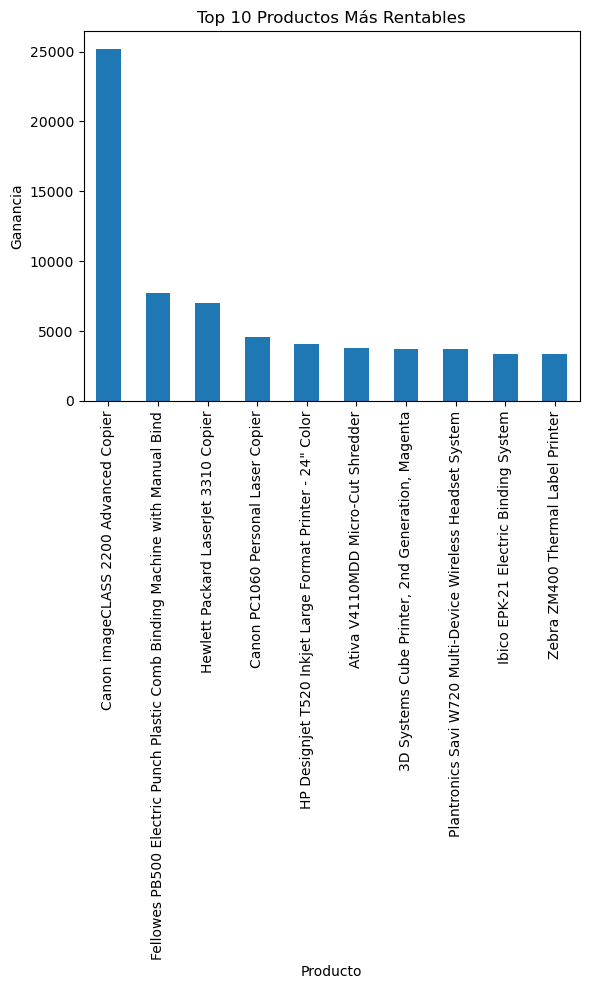

In [15]:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Productos Más Rentables")
plt.xlabel("Producto")
plt.ylabel("Ganancia")

plt.show()

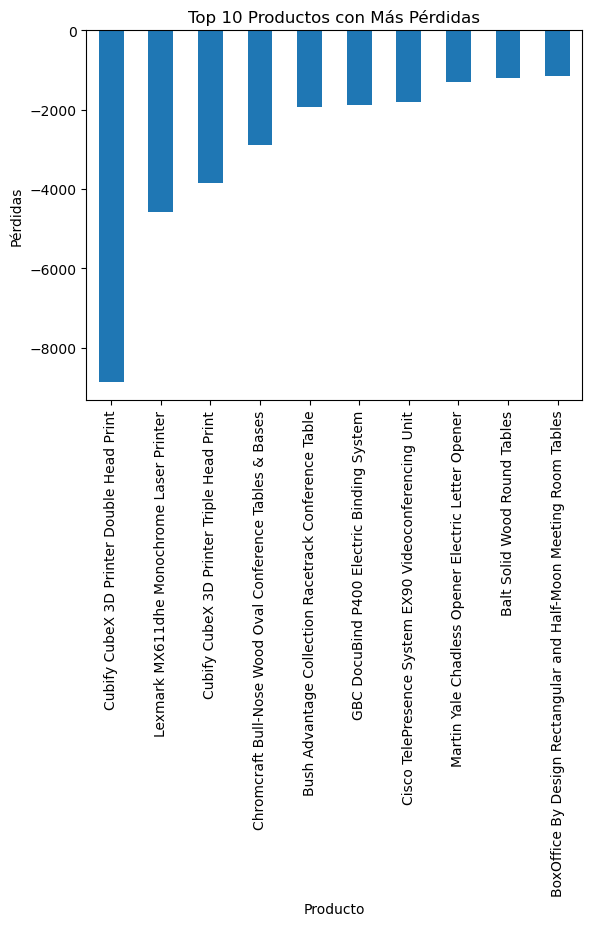

In [16]:
worst_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

worst_products.plot(kind="bar")

plt.title("Top 10 Productos con Más Pérdidas")
plt.xlabel("Producto")
plt.ylabel("Pérdidas")

plt.show()